# Notebook 4: Overall and Zone-Level Model Evaluation

This notebook evaluates the saved testing predictions produced by the baseline and enriched modelling notebooks. It does not train or tune any model.

The evaluation has three connected purposes:

1. compare overall Random Forest and XGBoost performance;
2. measure prediction performance separately for every analysis-ready taxi zone; and
3. determine whether the contextual features improve predictions in low-demand outer-borough zones.

`LocationID` is used only to group and report results. It is never supplied as a model predictor.


## 1. Environment and required files

Run Notebooks 1, 2 and 3 before this notebook. Notebook 4 expects the saved baseline and enriched testing-prediction files and the baseline training partition used to define low-demand zones.


In [2]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")

WINDOWS_OUTPUTS = Path(
    r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs"
)
PROCESSED_OUTPUTS = Path(os.environ.get("NYC_TAXI_PROCESSED_OUTPUTS", WINDOWS_OUTPUTS))
DATA_DIR = PROCESSED_OUTPUTS / "model_datasets"
MODEL_RESULTS_DIR = PROCESSED_OUTPUTS / "model_results"
BASELINE_RESULTS_DIR = MODEL_RESULTS_DIR / "baseline"
ENRICHED_RESULTS_DIR = MODEL_RESULTS_DIR / "enriched"
EVALUATION_RESULTS_DIR = MODEL_RESULTS_DIR / "evaluation"
EVALUATION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_PREDICTIONS_PATH = BASELINE_RESULTS_DIR / "baseline_test_predictions.csv"
ENRICHED_PREDICTIONS_PATH = ENRICHED_RESULTS_DIR / "enriched_test_predictions.csv"
TRAINING_PATH = DATA_DIR / "nyc_yellow_taxi_baseline_train_2025_q1.csv"

print(f"Baseline results: {BASELINE_RESULTS_DIR}")
print(f"Enriched results: {ENRICHED_RESULTS_DIR}")
print(f"Evaluation outputs: {EVALUATION_RESULTS_DIR}")


Baseline results: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_results\baseline
Enriched results: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_results\enriched
Evaluation outputs: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_results\evaluation


## 2. Load and align the saved testing predictions

The same 111,888 zone-hour observations must appear in both prediction files. The actual demand and identifying metadata must also match before any comparison is calculated.


In [3]:
# Confirm that all required inputs are available.
required_files = [BASELINE_PREDICTIONS_PATH, ENRICHED_PREDICTIONS_PATH, TRAINING_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Run the earlier notebooks first. Missing file(s):\n" + "\n".join(missing_files)
    )

# Load the saved testing predictions and training metadata.
baseline_predictions = pd.read_csv(BASELINE_PREDICTIONS_PATH, parse_dates=["pickup_hour"])
enriched_predictions = pd.read_csv(ENRICHED_PREDICTIONS_PATH, parse_dates=["pickup_hour"])
training_data = pd.read_csv(TRAINING_PATH, parse_dates=["pickup_hour"])

KEY_COLUMNS = ["LocationID", "borough", "zone", "pickup_hour"]
ACTUAL_COLUMN = "actual_pickups"
PREDICTION_COLUMNS = [
    "random_forest_default",
    "random_forest_tuned",
    "xgboost_default",
    "xgboost_tuned",
]
REQUIRED_PREDICTION_COLUMNS = KEY_COLUMNS + [ACTUAL_COLUMN] + PREDICTION_COLUMNS

# Apply the same integrity checks to both prediction files.
for name, frame in {
    "Baseline": baseline_predictions,
    "Enriched": enriched_predictions,
}.items():
    missing_columns = sorted(set(REQUIRED_PREDICTION_COLUMNS) - set(frame.columns))
    assert not missing_columns, f"{name} predictions are missing: {missing_columns}"
    assert frame[REQUIRED_PREDICTION_COLUMNS].isna().sum().sum() == 0
    assert not frame.duplicated(["LocationID", "pickup_hour"]).any()

# Sort both files and verify exact row alignment.
baseline_predictions = baseline_predictions.sort_values(["LocationID", "pickup_hour"]).reset_index(drop=True)
enriched_predictions = enriched_predictions.sort_values(["LocationID", "pickup_hour"]).reset_index(drop=True)

assert baseline_predictions[KEY_COLUMNS].equals(enriched_predictions[KEY_COLUMNS])
assert baseline_predictions[ACTUAL_COLUMN].equals(enriched_predictions[ACTUAL_COLUMN])

input_check = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": len(frame),
        "Taxi zones": frame["LocationID"].nunique(),
        "Hours": frame["pickup_hour"].nunique(),
        "Start": frame["pickup_hour"].min(),
        "End": frame["pickup_hour"].max(),
    }
    for name, frame in {
        "Baseline": baseline_predictions,
        "Enriched": enriched_predictions,
    }.items()
])
display(input_check)


,Dataset,Rows,Taxi zones,Hours,Start,End
0,Baseline,111888,259,432,2025-03-14,2025-03-31 23:00:00
1,Enriched,111888,259,432,2025-03-14,2025-03-31 23:00:00


In [4]:
def predictions_to_long(frame, dataset_name):
    # Convert one wide prediction file into a consistent long table.
    long_frame = frame.melt(
        id_vars=KEY_COLUMNS + [ACTUAL_COLUMN],
        value_vars=PREDICTION_COLUMNS,
        var_name="Model key",
        value_name="Predicted pickups",
    )
    model_details = long_frame["Model key"].str.extract(
        r"(?P<Algorithm>random_forest|xgboost)_(?P<Configuration>default|tuned)"
    )
    long_frame["Dataset"] = dataset_name
    long_frame["Algorithm"] = model_details["Algorithm"].map({
        "random_forest": "Random Forest",
        "xgboost": "XGBoost",
    })
    long_frame["Configuration"] = model_details["Configuration"].str.title()
    long_frame["Model"] = (
        long_frame["Dataset"] + " | " +
        long_frame["Algorithm"] + " | " +
        long_frame["Configuration"]
    )
    return long_frame


# Combine all eight model configurations in one aligned table.
predictions_long = pd.concat([
    predictions_to_long(baseline_predictions, "Baseline"),
    predictions_to_long(enriched_predictions, "Enriched"),
], ignore_index=True)

model_order = [
    f"{dataset} | {algorithm} | {configuration}"
    for dataset in ["Baseline", "Enriched"]
    for algorithm in ["Random Forest", "XGBoost"]
    for configuration in ["Default", "Tuned"]
]

print(f"Evaluation rows after reshaping: {len(predictions_long):,}")
print(f"Models included: {predictions_long['Model'].nunique()}")


Evaluation rows after reshaping: 895,104
Models included: 8


## 3. Overall testing performance

RMSE is the primary metric because large errors receive a stronger penalty. MAE describes the average absolute error in pickups, while (R^2) shows how much variation in demand is explained. Accuracy and MAPE are not used because this is a regression problem with many zero-demand observations.


In [5]:
def calculate_metrics(actual, predicted):
    # Calculate the three regression metrics used consistently throughout the study.
    return {
        "RMSE": float(np.sqrt(mean_squared_error(actual, predicted))),
        "MAE": float(mean_absolute_error(actual, predicted)),
        "R2": float(r2_score(actual, predicted)),
    }


# Calculate overall test metrics using every zone-hour observation.
overall_rows = []
for (dataset, algorithm, configuration, model_name), group in predictions_long.groupby(
    ["Dataset", "Algorithm", "Configuration", "Model"], sort=False
):
    overall_rows.append({
        "Dataset": dataset,
        "Algorithm": algorithm,
        "Configuration": configuration,
        "Model": model_name,
        **calculate_metrics(group[ACTUAL_COLUMN], group["Predicted pickups"]),
    })

overall_metrics = pd.DataFrame(overall_rows)
overall_metrics["Model"] = pd.Categorical(overall_metrics["Model"], model_order, ordered=True)
overall_metrics = overall_metrics.sort_values("Model").reset_index(drop=True)
display(overall_metrics.round(4))


,Dataset,Algorithm,Configuration,Model,RMSE,MAE,R2
0,Baseline,Random Forest,Default,Baseline | Random Forest | Default,54.6348,28.2677,0.0345
1,Baseline,Random Forest,Tuned,Baseline | Random Forest | Tuned,54.6256,28.2422,0.0349
2,Baseline,XGBoost,Default,Baseline | XGBoost | Default,54.6276,28.3391,0.0348
3,Baseline,XGBoost,Tuned,Baseline | XGBoost | Tuned,54.6447,28.3933,0.0342
4,Enriched,Random Forest,Default,Enriched | Random Forest | Default,11.5477,3.8465,0.9569
5,Enriched,Random Forest,Tuned,Enriched | Random Forest | Tuned,11.9725,3.9007,0.9536
6,Enriched,XGBoost,Default,Enriched | XGBoost | Default,13.3107,5.2677,0.9427
7,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,12.0126,4.4925,0.9533


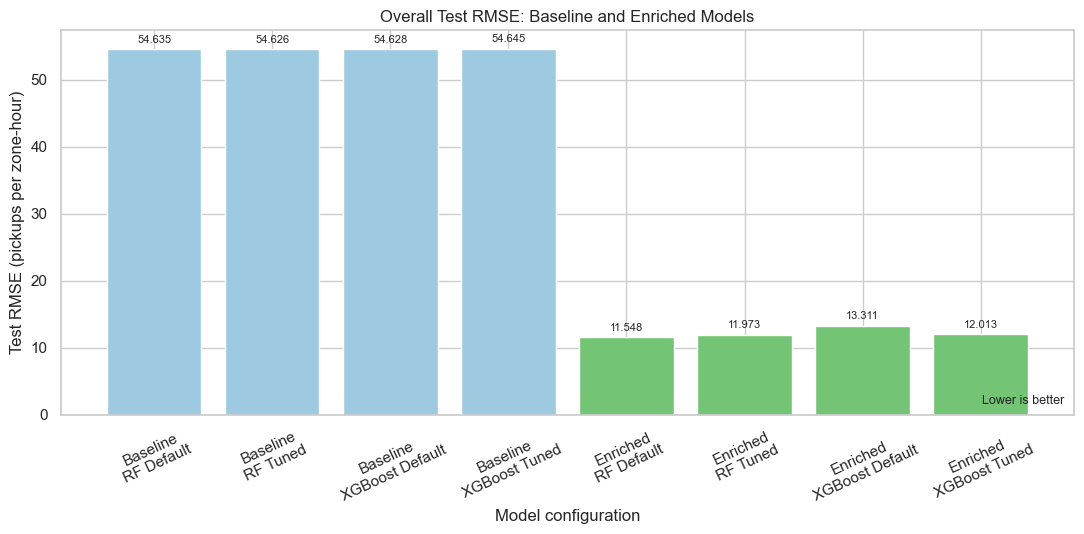

In [6]:
def plot_overall_metric(metric, ylabel, title, higher_is_better=False):
    # Draw one metric on its own numerical scale.
    chart = overall_metrics.copy()
    chart["Label"] = (
        chart["Dataset"] + "\n" +
        chart["Algorithm"].str.replace("Random Forest", "RF") + " " +
        chart["Configuration"]
    )
    colours = ["#9ecae1" if dataset == "Baseline" else "#74c476" for dataset in chart["Dataset"]]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars = ax.bar(chart["Label"], chart[metric], color=colours)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set(title=title, xlabel="Model configuration", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=25)
    direction = "Higher is better" if higher_is_better else "Lower is better"
    ax.text(0.99, 0.02, direction, transform=ax.transAxes, ha="right", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


# Plot overall RMSE separately because it is the primary metric.
plot_overall_metric(
    metric="RMSE",
    ylabel="Test RMSE (pickups per zone-hour)",
    title="Overall Test RMSE: Baseline and Enriched Models",
)


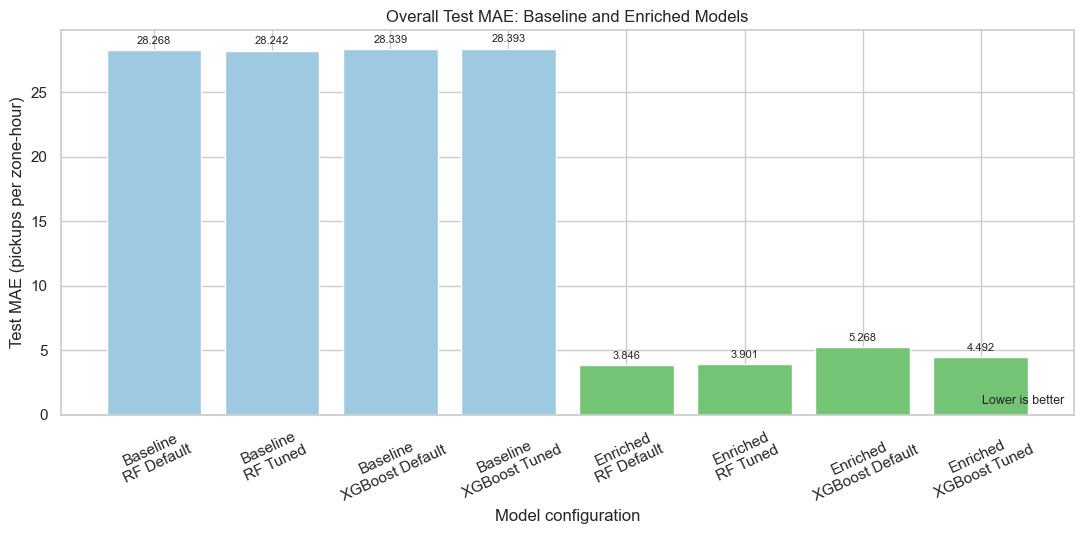

In [7]:
# Plot overall MAE on its own scale.
plot_overall_metric(
    metric="MAE",
    ylabel="Test MAE (pickups per zone-hour)",
    title="Overall Test MAE: Baseline and Enriched Models",
)


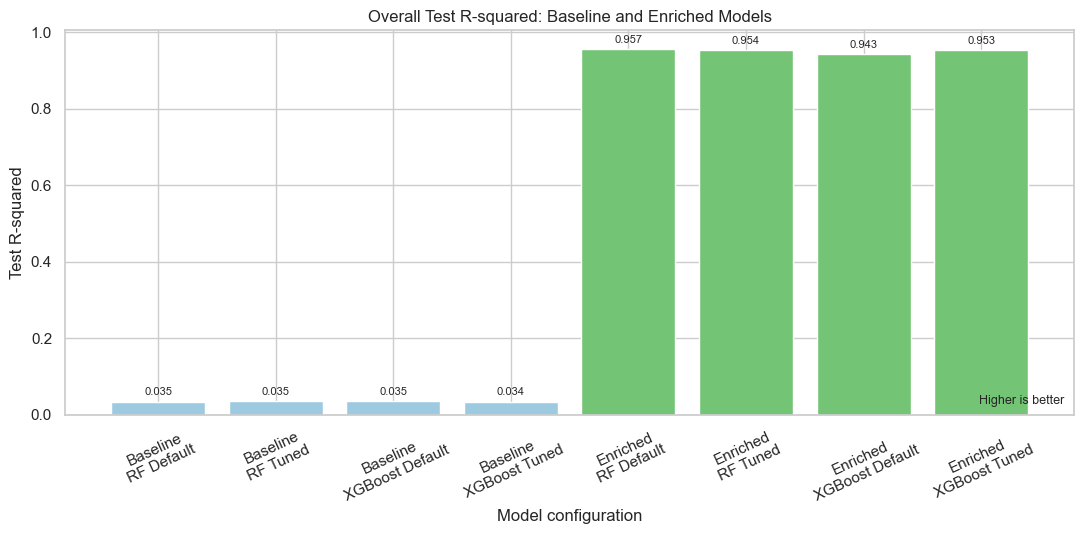

In [8]:
# Plot overall R-squared separately because higher values are better.
plot_overall_metric(
    metric="R2",
    ylabel="Test R-squared",
    title="Overall Test R-squared: Baseline and Enriched Models",
    higher_is_better=True,
)


In [9]:
# Compare each enriched model with the matching baseline model.
overall_baseline = overall_metrics.loc[
    overall_metrics["Dataset"].eq("Baseline"),
    ["Algorithm", "Configuration", "RMSE", "MAE", "R2"],
].rename(columns={"RMSE": "Baseline RMSE", "MAE": "Baseline MAE", "R2": "Baseline R2"})

overall_enriched = overall_metrics.loc[
    overall_metrics["Dataset"].eq("Enriched"),
    ["Algorithm", "Configuration", "RMSE", "MAE", "R2"],
].rename(columns={"RMSE": "Enriched RMSE", "MAE": "Enriched MAE", "R2": "Enriched R2"})

overall_improvements = overall_baseline.merge(
    overall_enriched,
    on=["Algorithm", "Configuration"],
    validate="one_to_one",
)
overall_improvements["RMSE reduction"] = (
    overall_improvements["Baseline RMSE"] - overall_improvements["Enriched RMSE"]
)
overall_improvements["RMSE reduction (%)"] = (
    overall_improvements["RMSE reduction"] / overall_improvements["Baseline RMSE"] * 100
)
overall_improvements["MAE reduction (%)"] = (
    (overall_improvements["Baseline MAE"] - overall_improvements["Enriched MAE"])
    / overall_improvements["Baseline MAE"] * 100
)
overall_improvements["R2 change"] = (
    overall_improvements["Enriched R2"] - overall_improvements["Baseline R2"]
)
display(overall_improvements.round(4))


,Algorithm,Configuration,Baseline RMSE,Baseline MAE,Baseline R2,Enriched RMSE,Enriched MAE,Enriched R2,RMSE reduction,RMSE reduction (%),MAE reduction (%),R2 change
0,Random Forest,Default,54.6348,28.2677,0.0345,11.5477,3.8465,0.9569,43.0871,78.8638,86.3927,0.9223
1,Random Forest,Tuned,54.6256,28.2422,0.0349,11.9725,3.9007,0.9536,42.6531,78.0826,86.1885,0.9188
2,XGBoost,Default,54.6276,28.3391,0.0348,13.3107,5.2677,0.9427,41.3169,75.6338,81.4119,0.9079
3,XGBoost,Tuned,54.6447,28.3933,0.0342,12.0126,4.4925,0.9533,42.6321,78.0168,84.1776,0.9191


## 4. Individual taxi-zone performance

Every zone is evaluated using its 432 hourly testing observations. A zone's (R^2) is left undefined when its actual demand has no variation, because replacing an undefined value with zero would change its statistical meaning.


In [10]:
def safe_r2(actual, predicted):
    # Return undefined R-squared when actual demand has no variation.
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    if np.sum((actual - actual.mean()) ** 2) == 0:
        return np.nan
    return float(r2_score(actual, predicted))


def calculate_zone_metrics(group):
    # Summarise prediction performance for one model in one taxi zone.
    actual = group[ACTUAL_COLUMN].to_numpy()
    predicted = group["Predicted pickups"].to_numpy()
    return pd.Series({
        "Test observations": len(group),
        "Mean actual demand": actual.mean(),
        "Actual total pickups": actual.sum(),
        "Predicted total pickups": predicted.sum(),
        "Mean bias": (predicted - actual).mean(),
        "Zone RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "Zone MAE": mean_absolute_error(actual, predicted),
        "Zone R2": safe_r2(actual, predicted),
    })


# Calculate RMSE, MAE and R-squared separately for every taxi zone and model.
zone_metrics = (
    predictions_long.groupby(
        ["Dataset", "Algorithm", "Configuration", "Model", "LocationID", "borough", "zone"],
        observed=True,
        sort=False,
    )
    .apply(calculate_zone_metrics, include_groups=False)
    .reset_index()
)

# Standardise zone RMSE only within the same model configuration.
def standardise_rmse(values):
    standard_deviation = values.std(ddof=0)
    if standard_deviation == 0:
        return pd.Series(np.zeros(len(values)), index=values.index)
    return (values - values.mean()) / standard_deviation


zone_metrics["Zone RMSE z-score"] = zone_metrics.groupby(
    ["Dataset", "Algorithm", "Configuration"], observed=True
)["Zone RMSE"].transform(standardise_rmse)
zone_metrics["Unusually high error"] = zone_metrics["Zone RMSE z-score"] >= 2

display(zone_metrics.head(12).round(4))
print(f"Zone-model rows: {len(zone_metrics):,}")


,Dataset,Algorithm,Configuration,Model,LocationID,borough,zone,Test observations,Mean actual demand,Actual total pickups,Predicted total pickups,Mean bias,Zone RMSE,Zone MAE,Zone R2,Zone RMSE z-score,Unusually high error
0,Baseline,Random Forest,Default,Baseline | Random Forest | Default,2,Queens,Jamaica Bay,432.0,0.0069,3.0,8303.6339,19.2144,21.8854,19.2144,-69453.3251,-0.3103,False
1,Baseline,Random Forest,Default,Baseline | Random Forest | Default,3,Bronx,Allerton/Pelham Gardens,432.0,0.5278,228.0,8303.6339,18.6936,21.4430,18.6942,-724.8270,-0.3209,False
2,Baseline,Random Forest,Default,Baseline | Random Forest | Default,4,Manhattan,Alphabet City,432.0,15.7847,6819.0,8303.6339,3.4367,23.5052,15.0960,0.0399,-0.2718,False
3,Baseline,Random Forest,Default,Baseline | Random Forest | Default,5,Staten Island,Arden Heights,432.0,0.0000,0.0,8303.6339,19.2214,21.8915,19.2214,NaN,-0.3102,False
4,Baseline,Random Forest,Default,Baseline | Random Forest | Default,6,Staten Island,Arrochar/Fort Wadsworth,432.0,0.1181,51.0,8303.6339,19.1033,21.7781,19.1033,-4182.2357,-0.3129,False
5,Baseline,Random Forest,Default,Baseline | Random Forest | Default,7,Queens,Astoria,432.0,8.9722,3876.0,8303.6339,10.2492,15.6843,12.8783,-3.0899,-0.4579,False
6,Baseline,Random Forest,Default,Baseline | Random Forest | Default,8,Queens,Astoria Park,432.0,0.0394,17.0,8303.6339,19.1820,21.8513,19.1820,-11251.5661,-0.3111,False
7,Baseline,Random Forest,Default,Baseline | Random Forest | Default,9,Queens,Auburndale,432.0,0.1713,74.0,8303.6339,19.0501,21.7289,19.0501,-2184.5774,-0.3140,False
8,Baseline,Random Forest,Default,Baseline | Random Forest | Default,10,Queens,Baisley Park,432.0,2.4167,1044.0,8303.6339,16.8047,19.7276,16.8789,-99.4928,-0.3617,False
9,Baseline,Random Forest,Default,Baseline | Random Forest | Default,11,Brooklyn,Bath Beach,432.0,0.3241,140.0,8303.6339,18.8973,21.6050,18.8974,-1303.0663,-0.3170,False


Zone-model rows: 2,072


In [11]:
# Summarise the distribution of individual-zone performance.
zone_performance_summary = (
    zone_metrics.groupby(["Dataset", "Algorithm", "Configuration", "Model"], observed=True)
    .agg(
        Zones=("LocationID", "nunique"),
        Median_zone_RMSE=("Zone RMSE", "median"),
        Mean_zone_RMSE=("Zone RMSE", "mean"),
        Median_zone_MAE=("Zone MAE", "median"),
        Median_zone_R2=("Zone R2", "median"),
        Negative_zone_R2_count=("Zone R2", lambda values: int((values < 0).sum())),
        Undefined_zone_R2_count=("Zone R2", lambda values: int(values.isna().sum())),
        High_error_zone_count=("Unusually high error", "sum"),
    )
    .reset_index()
)
display(zone_performance_summary.round(4))


,Dataset,Algorithm,Configuration,Model,Zones,Median_zone_RMSE,Mean_zone_RMSE,Median_zone_MAE,Median_zone_R2,Negative_zone_R2_count,Undefined_zone_R2_count,High_error_zone_count
0,Baseline,Random Forest,Default,Baseline | Random Forest | Default,259,21.1689,34.9238,18.3861,-136.5213,242,6,17
1,Baseline,Random Forest,Tuned,Baseline | Random Forest | Tuned,259,21.2021,34.9383,18.3368,-136.9854,242,6,17
2,Baseline,XGBoost,Default,Baseline | XGBoost | Default,259,21.3293,35.0205,18.5025,-138.5460,242,6,17
3,Baseline,XGBoost,Tuned,Baseline | XGBoost | Tuned,259,20.9118,34.7736,18.5533,-132.5475,243,6,17
4,Enriched,Random Forest,Default,Enriched | Random Forest | Default,259,1.5402,5.8107,1.1110,0.1829,76,6,13
5,Enriched,Random Forest,Tuned,Enriched | Random Forest | Tuned,259,1.5239,5.9429,1.0920,0.2294,28,6,15
6,Enriched,XGBoost,Default,Enriched | XGBoost | Default,259,2.6911,7.4732,1.8730,-0.2048,159,6,14
7,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,259,2.3575,6.5431,1.5962,-0.0716,141,6,14


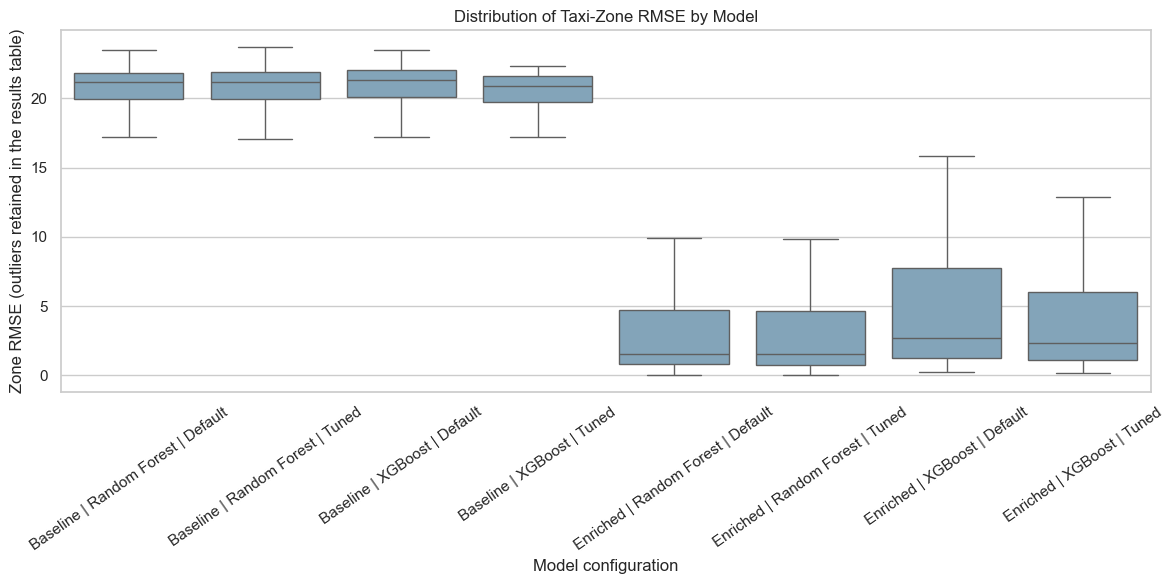

In [12]:
# Plot the typical zone RMSE distribution without hiding the full values from the exported table.
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=zone_metrics,
    x="Model",
    y="Zone RMSE",
    order=model_order,
    showfliers=False,
    color="#7aa6c2",
    ax=ax,
)
ax.set(
    title="Distribution of Taxi-Zone RMSE by Model",
    xlabel="Model configuration",
    ylabel="Zone RMSE (outliers retained in the results table)",
)
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


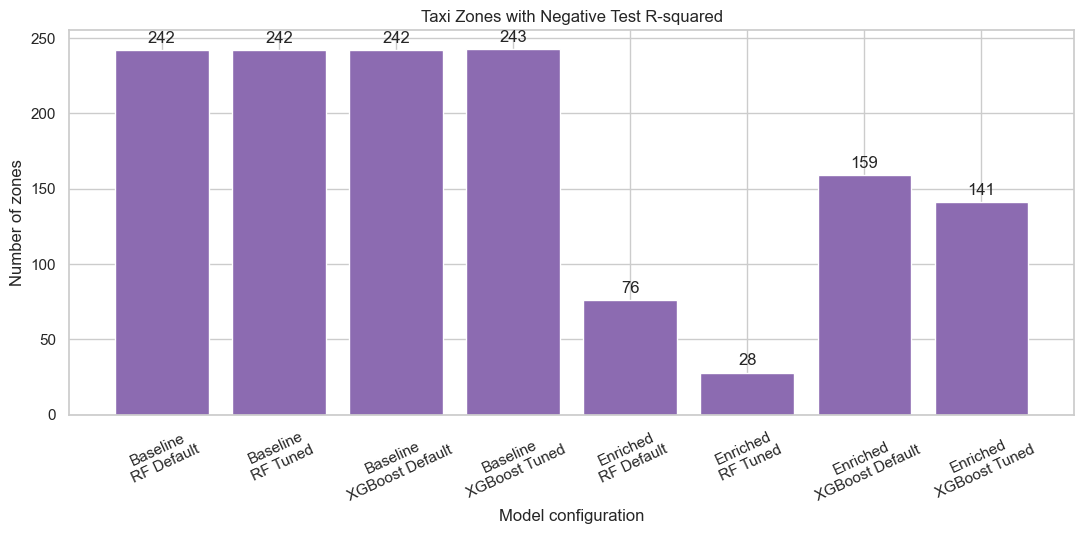

In [13]:
# Plot the number of zones with negative R-squared for each model.
negative_r2_chart = zone_performance_summary.copy()
negative_r2_chart["Label"] = (
    negative_r2_chart["Dataset"] + "\n" +
    negative_r2_chart["Algorithm"].str.replace("Random Forest", "RF") + " " +
    negative_r2_chart["Configuration"]
)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(negative_r2_chart["Label"], negative_r2_chart["Negative_zone_R2_count"], color="#8c6bb1")
ax.bar_label(bars, padding=3)
ax.set(
    title="Taxi Zones with Negative Test R-squared",
    xlabel="Model configuration",
    ylabel="Number of zones",
)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


## 5. Zone-level baseline versus enriched comparison

For the same algorithm and configuration, a positive RMSE reduction means that the enriched model improved the prediction for that zone. Negative values show where contextual enrichment made the prediction worse.


In [14]:
# Join matching baseline and enriched zone results.
zone_comparison_columns = [
    "Algorithm", "Configuration", "LocationID", "borough", "zone",
    "Mean actual demand", "Zone RMSE", "Zone MAE", "Zone R2",
]
baseline_zone_metrics = zone_metrics.loc[
    zone_metrics["Dataset"].eq("Baseline"), zone_comparison_columns
].rename(columns={
    "Zone RMSE": "Baseline zone RMSE",
    "Zone MAE": "Baseline zone MAE",
    "Zone R2": "Baseline zone R2",
})
enriched_zone_metrics = zone_metrics.loc[
    zone_metrics["Dataset"].eq("Enriched"),
    ["Algorithm", "Configuration", "LocationID", "Zone RMSE", "Zone MAE", "Zone R2"],
].rename(columns={
    "Zone RMSE": "Enriched zone RMSE",
    "Zone MAE": "Enriched zone MAE",
    "Zone R2": "Enriched zone R2",
})

zone_improvements = baseline_zone_metrics.merge(
    enriched_zone_metrics,
    on=["Algorithm", "Configuration", "LocationID"],
    validate="one_to_one",
)
zone_improvements["Zone RMSE reduction"] = (
    zone_improvements["Baseline zone RMSE"] - zone_improvements["Enriched zone RMSE"]
)
zone_improvements["Zone RMSE reduction (%)"] = np.where(
    zone_improvements["Baseline zone RMSE"] > 0,
    zone_improvements["Zone RMSE reduction"] / zone_improvements["Baseline zone RMSE"] * 100,
    np.nan,
)
zone_improvements["Zone MAE reduction (%)"] = np.where(
    zone_improvements["Baseline zone MAE"] > 0,
    (zone_improvements["Baseline zone MAE"] - zone_improvements["Enriched zone MAE"])
    / zone_improvements["Baseline zone MAE"] * 100,
    np.nan,
)
zone_improvements["Zone R2 change"] = (
    zone_improvements["Enriched zone R2"] - zone_improvements["Baseline zone R2"]
)
zone_improvements["RMSE improved"] = zone_improvements["Zone RMSE reduction"] > 0

zone_improvement_summary = (
    zone_improvements.groupby(["Algorithm", "Configuration"], observed=True)
    .agg(
        Zones=("LocationID", "nunique"),
        Improved_zones=("RMSE improved", "sum"),
        Median_RMSE_reduction=("Zone RMSE reduction", "median"),
        Median_RMSE_reduction_percent=("Zone RMSE reduction (%)", "median"),
        Median_R2_change=("Zone R2 change", "median"),
    )
    .reset_index()
)
zone_improvement_summary["Improved zones (%)"] = (
    zone_improvement_summary["Improved_zones"] / zone_improvement_summary["Zones"] * 100
)
display(zone_improvement_summary.round(4))


,Algorithm,Configuration,Zones,Improved_zones,Median_RMSE_reduction,Median_RMSE_reduction_percent,Median_R2_change,Improved zones (%)
0,Random Forest,Default,259,259,20.0329,92.5164,136.7117,100.0000
1,Random Forest,Tuned,259,259,20.0718,92.5225,137.0601,100.0000
2,XGBoost,Default,259,258,19.3403,86.7569,133.0017,99.6139
3,XGBoost,Tuned,259,259,19.1236,88.4416,132.5142,100.0000


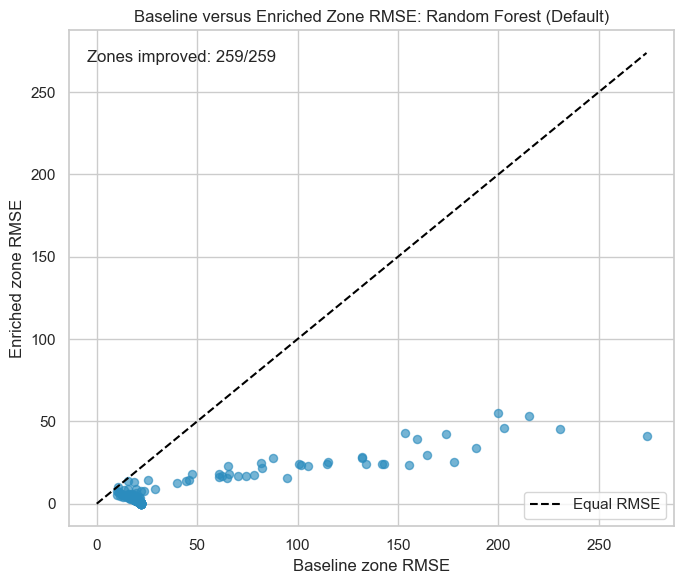

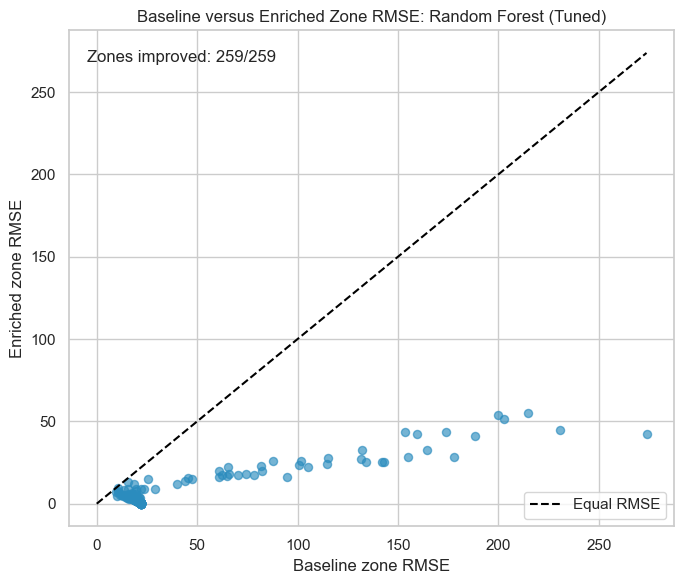

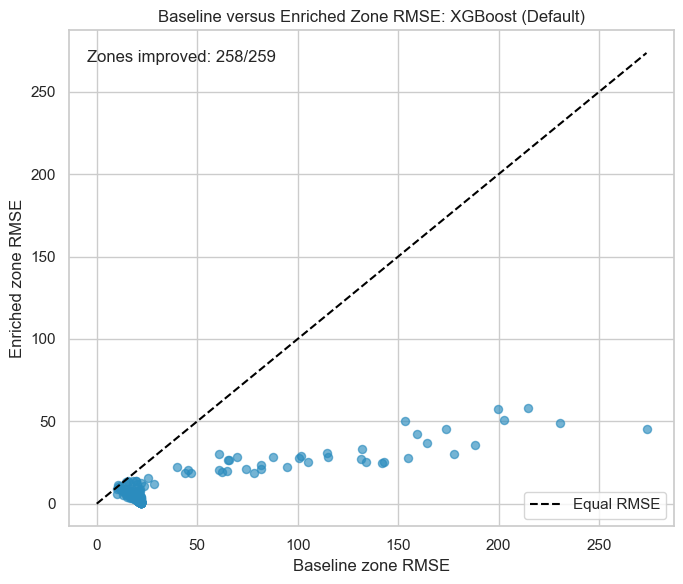

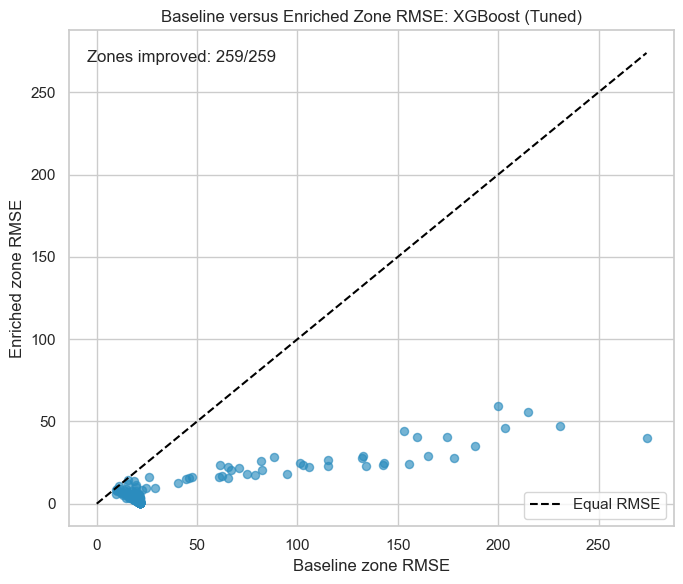

In [15]:
# Draw one baseline-versus-enriched scatter plot for each matched model pair.
for (algorithm, configuration), group in zone_improvements.groupby(["Algorithm", "Configuration"], sort=False):
    upper_limit = max(group["Baseline zone RMSE"].max(), group["Enriched zone RMSE"].max())
    improved_count = int(group["RMSE improved"].sum())

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(
        group["Baseline zone RMSE"],
        group["Enriched zone RMSE"],
        alpha=0.65,
        s=34,
        color="#2b8cbe",
    )
    ax.plot([0, upper_limit], [0, upper_limit], color="black", linestyle="--", label="Equal RMSE")
    ax.set(
        title=f"Baseline versus Enriched Zone RMSE: {algorithm} ({configuration})",
        xlabel="Baseline zone RMSE",
        ylabel="Enriched zone RMSE",
    )
    ax.text(
        0.03,
        0.96,
        f"Zones improved: {improved_count}/{len(group)}",
        transform=ax.transAxes,
        va="top",
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


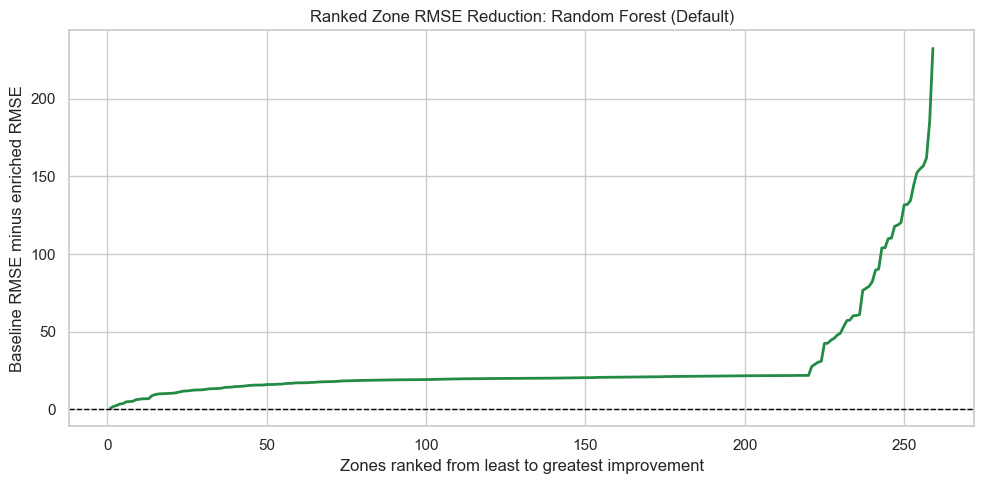

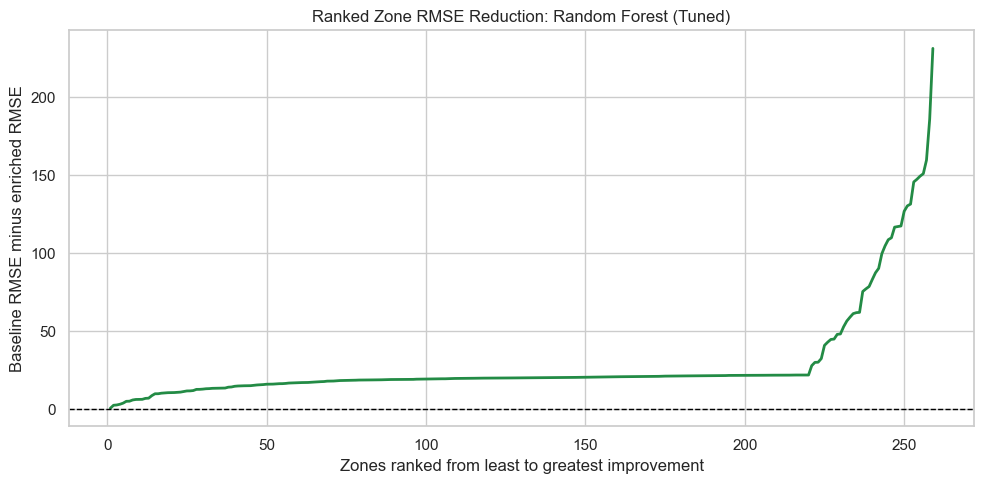

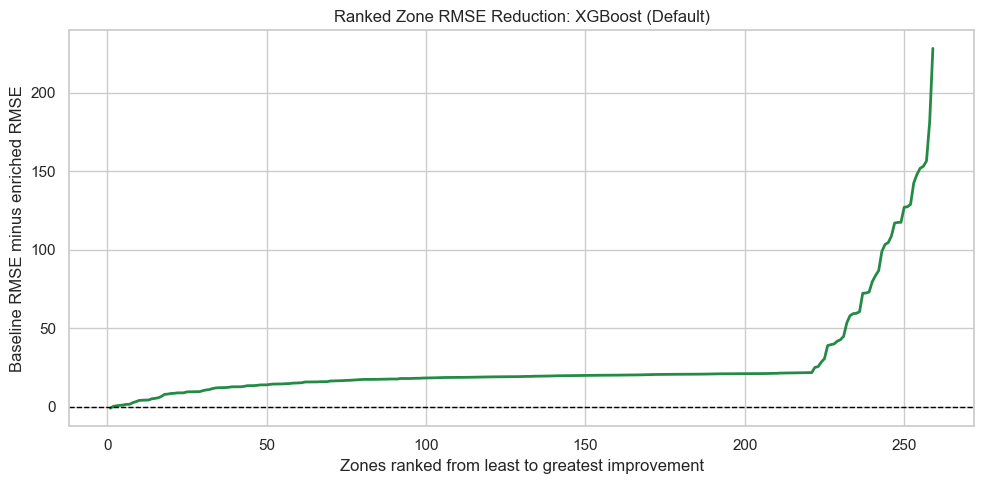

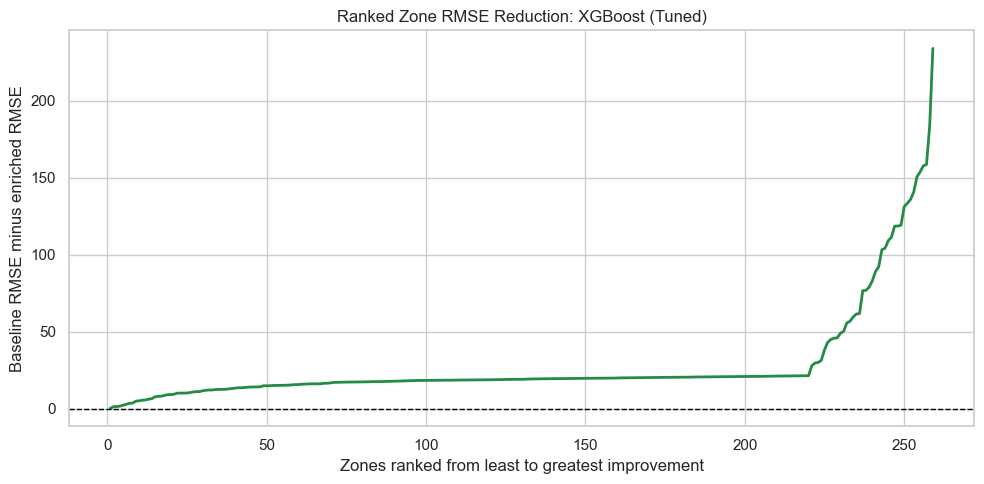

In [16]:
# Rank every zone by its absolute RMSE reduction for each matched model pair.
for (algorithm, configuration), group in zone_improvements.groupby(["Algorithm", "Configuration"], sort=False):
    ranked = group.sort_values("Zone RMSE reduction").reset_index(drop=True)
    ranked["Zone rank"] = np.arange(1, len(ranked) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(ranked["Zone rank"], ranked["Zone RMSE reduction"], color="#238b45", linewidth=2)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set(
        title=f"Ranked Zone RMSE Reduction: {algorithm} ({configuration})",
        xlabel="Zones ranked from least to greatest improvement",
        ylabel="Baseline RMSE minus enriched RMSE",
    )
    plt.tight_layout()
    plt.show()


## 6. Low-demand outer-borough evaluation

Low-demand zones are defined only from the training partition to keep the testing period independent. The bottom quartile of mean hourly training demand is calculated among zones in the Bronx, Brooklyn, Queens and Staten Island. That fixed zone list is then used for every model comparison.


In [17]:
# Define low-demand outer-borough zones using training data only.
OUTER_BOROUGHS = ["Bronx", "Brooklyn", "Queens", "Staten Island"]
LOW_DEMAND_QUANTILE = 0.25

training_zone_demand = (
    training_data.groupby(["LocationID", "borough", "zone"], as_index=False)
    .agg(
        Training_mean_hourly_demand=("pickup_count", "mean"),
        Training_total_pickups=("pickup_count", "sum"),
    )
)
outer_zone_demand = training_zone_demand.loc[
    training_zone_demand["borough"].isin(OUTER_BOROUGHS)
].copy()
low_demand_threshold = outer_zone_demand["Training_mean_hourly_demand"].quantile(LOW_DEMAND_QUANTILE)
low_demand_zones = outer_zone_demand.loc[
    outer_zone_demand["Training_mean_hourly_demand"] <= low_demand_threshold
].copy()
low_demand_zone_ids = set(low_demand_zones["LocationID"])

print(f"Outer-borough zones considered: {len(outer_zone_demand)}")
print(f"Training-demand threshold: {low_demand_threshold:.4f} pickups per zone-hour")
print(f"Low-demand outer-borough zones selected: {len(low_demand_zones)}")
display(low_demand_zones.sort_values("Training_mean_hourly_demand").head(15).round(4))


Outer-borough zones considered: 193
Training-demand threshold: 0.2093 pickups per zone-hour
Low-demand outer-borough zones selected: 49


,LocationID,borough,zone,Training_mean_hourly_demand,Training_total_pickups
42,44,Staten Island,Charleston/Tottenville,0.0000,0
105,110,Staten Island,Great Kills Park,0.0000,0
82,84,Staten Island,Eltingville/Annadale/Prince's Bay,0.0008,1
97,99,Staten Island,Freshkills Park,0.0008,1
194,199,Bronx,Rikers Island,0.0015,2
182,187,Staten Island,Port Richmond,0.0015,2
3,5,Staten Island,Arden Heights,0.0023,3
199,204,Staten Island,Rossville/Woodrow,0.0023,3
104,109,Staten Island,Great Kills,0.0031,4
106,111,Brooklyn,Green-Wood Cemetery,0.0039,5


In [18]:
# Calculate pooled test metrics across all low-demand zone-hour observations.
low_demand_predictions = predictions_long.loc[
    predictions_long["LocationID"].isin(low_demand_zone_ids)
].copy()

low_demand_pooled_rows = []
for (dataset, algorithm, configuration, model_name), group in low_demand_predictions.groupby(
    ["Dataset", "Algorithm", "Configuration", "Model"], sort=False
):
    low_demand_pooled_rows.append({
        "Dataset": dataset,
        "Algorithm": algorithm,
        "Configuration": configuration,
        "Model": model_name,
        "Zones": group["LocationID"].nunique(),
        "Observations": len(group),
        **calculate_metrics(group[ACTUAL_COLUMN], group["Predicted pickups"]),
    })

low_demand_pooled_metrics = pd.DataFrame(low_demand_pooled_rows)
display(low_demand_pooled_metrics.round(4))


,Dataset,Algorithm,Configuration,Model,Zones,Observations,RMSE,MAE,R2
0,Baseline,Random Forest,Default,Baseline | Random Forest | Default,49,21168,21.8040,19.1251,-3673.6136
1,Baseline,Random Forest,Tuned,Baseline | Random Forest | Tuned,49,21168,21.8315,19.0940,-3682.9169
2,Baseline,XGBoost,Default,Baseline | XGBoost | Default,49,21168,21.9651,19.2211,-3728.1213
3,Baseline,XGBoost,Tuned,Baseline | XGBoost | Tuned,49,21168,21.5524,19.3223,-3589.3198
4,Enriched,Random Forest,Default,Enriched | Random Forest | Default,49,21168,0.3632,0.1606,-0.0198
5,Enriched,Random Forest,Tuned,Enriched | Random Forest | Tuned,49,21168,0.3403,0.1567,0.1052
6,Enriched,XGBoost,Default,Enriched | XGBoost | Default,49,21168,1.3334,0.7495,-12.7428
7,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,49,21168,1.1096,0.5279,-8.5167


In [19]:
# Summarise individual-zone results within the low-demand group.
low_demand_zone_metrics = zone_metrics.loc[
    zone_metrics["LocationID"].isin(low_demand_zone_ids)
].copy()
low_demand_zone_summary = (
    low_demand_zone_metrics.groupby(["Dataset", "Algorithm", "Configuration", "Model"], observed=True)
    .agg(
        Zones=("LocationID", "nunique"),
        Median_zone_RMSE=("Zone RMSE", "median"),
        Median_zone_MAE=("Zone MAE", "median"),
        Median_zone_R2=("Zone R2", "median"),
        Negative_zone_R2_count=("Zone R2", lambda values: int((values < 0).sum())),
        Undefined_zone_R2_count=("Zone R2", lambda values: int(values.isna().sum())),
    )
    .reset_index()
)

low_demand_improvements = zone_improvements.loc[
    zone_improvements["LocationID"].isin(low_demand_zone_ids)
].copy()
low_demand_improvement_summary = (
    low_demand_improvements.groupby(["Algorithm", "Configuration"], observed=True)
    .agg(
        Low_demand_zones=("LocationID", "nunique"),
        Improved_zones=("RMSE improved", "sum"),
        Median_RMSE_reduction=("Zone RMSE reduction", "median"),
        Median_RMSE_reduction_percent=("Zone RMSE reduction (%)", "median"),
        Median_R2_change=("Zone R2 change", "median"),
    )
    .reset_index()
)
low_demand_improvement_summary["Improved zones (%)"] = (
    low_demand_improvement_summary["Improved_zones"]
    / low_demand_improvement_summary["Low_demand_zones"] * 100
)

display(low_demand_zone_summary.round(4))
display(low_demand_improvement_summary.round(4))


,Dataset,Algorithm,Configuration,Model,Zones,Median_zone_RMSE,Median_zone_MAE,Median_zone_R2,Negative_zone_R2_count,Undefined_zone_R2_count
0,Baseline,Random Forest,Default,Baseline | Random Forest | Default,49,21.8513,19.1820,-5827.4901,43,6
1,Baseline,Random Forest,Tuned,Baseline | Random Forest | Tuned,49,21.8781,19.1510,-5841.9667,43,6
2,Baseline,XGBoost,Default,Baseline | XGBoost | Default,49,22.0124,19.2764,-5913.6282,43,6
3,Baseline,XGBoost,Tuned,Baseline | XGBoost | Tuned,49,21.6014,19.3797,-5693.6129,43,6
4,Enriched,Random Forest,Default,Enriched | Random Forest | Default,49,0.2298,0.0994,-0.1733,40,6
5,Enriched,Random Forest,Tuned,Enriched | Random Forest | Tuned,49,0.2123,0.1019,0.0035,19,6
6,Enriched,XGBoost,Default,Enriched | XGBoost | Default,49,0.8464,0.6504,-10.7728,43,6
7,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,49,0.6936,0.4497,-6.8932,42,6


,Algorithm,Configuration,Low_demand_zones,Improved_zones,Median_RMSE_reduction,Median_RMSE_reduction_percent,Median_R2_change,Improved zones (%)
0,Random Forest,Default,49,49,21.6328,98.9489,5827.4765,100.0
1,Random Forest,Tuned,49,49,21.6652,99.0296,5841.9813,100.0
2,XGBoost,Default,49,49,21.1167,96.1433,5912.2418,100.0
3,XGBoost,Tuned,49,49,20.8861,96.7950,5692.9259,100.0


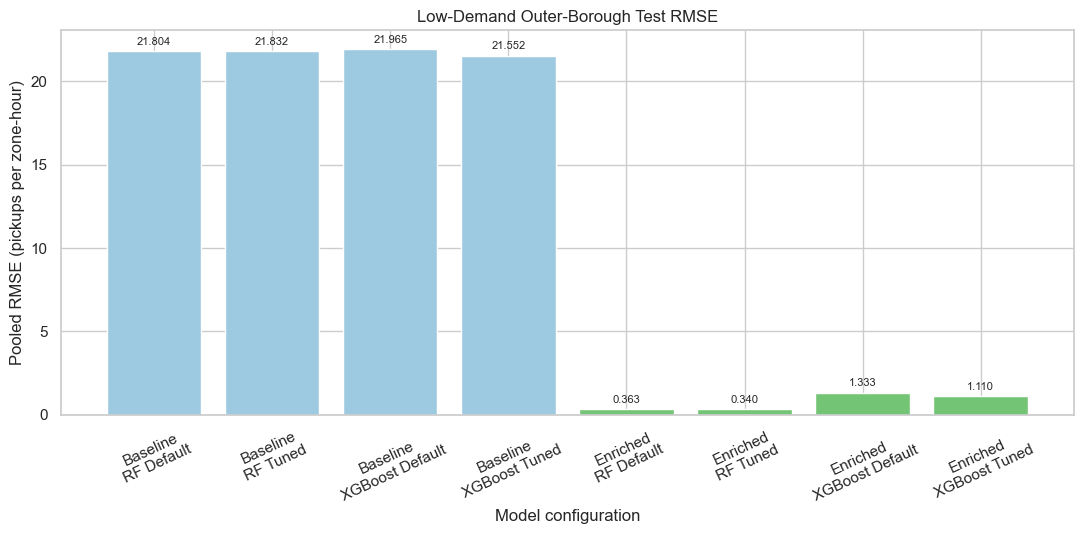

In [20]:
# Plot pooled RMSE for the low-demand outer-borough group.
low_chart = low_demand_pooled_metrics.copy()
low_chart["Label"] = (
    low_chart["Dataset"] + "\n" +
    low_chart["Algorithm"].str.replace("Random Forest", "RF") + " " +
    low_chart["Configuration"]
)
colours = ["#9ecae1" if dataset == "Baseline" else "#74c476" for dataset in low_chart["Dataset"]]

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(low_chart["Label"], low_chart["RMSE"], color=colours)
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
ax.set(
    title="Low-Demand Outer-Borough Test RMSE",
    xlabel="Model configuration",
    ylabel="Pooled RMSE (pickups per zone-hour)",
)
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


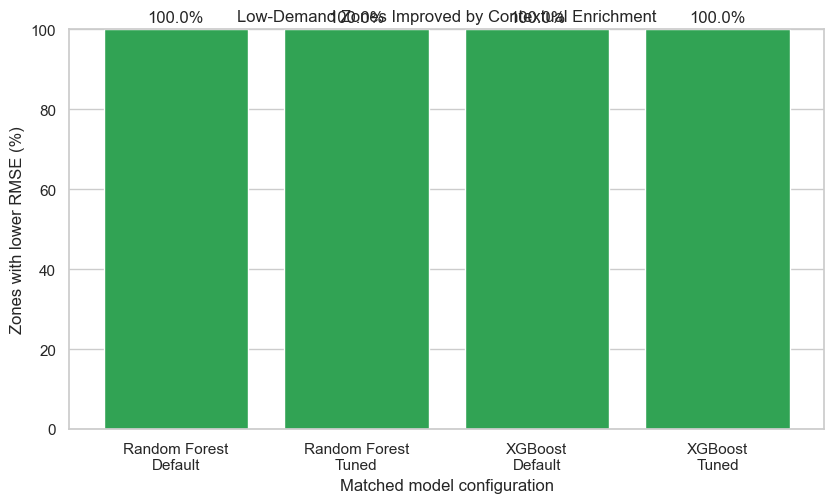

In [21]:
# Plot the percentage of low-demand zones improved by enrichment.
improvement_chart = low_demand_improvement_summary.copy()
improvement_chart["Label"] = improvement_chart["Algorithm"] + "\n" + improvement_chart["Configuration"]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(improvement_chart["Label"], improvement_chart["Improved zones (%)"], color="#31a354")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set(
    title="Low-Demand Zones Improved by Contextual Enrichment",
    xlabel="Matched model configuration",
    ylabel="Zones with lower RMSE (%)",
    ylim=(0, 100),
)
plt.tight_layout()
plt.show()


## 7. High-error zones for planning and dashboard use

The RMSE z-score is a relative flag, not a replacement for RMSE. A value of (+2) means that the zone's RMSE is at least two standard deviations above the average zone RMSE for that same model.


In [22]:
# List zones with unusually high error for at least one model.
high_error_zones = zone_metrics.loc[
    zone_metrics["Unusually high error"]
].sort_values(
    ["Dataset", "Algorithm", "Configuration", "Zone RMSE z-score"],
    ascending=[True, True, True, False],
)
display(high_error_zones.round(4))


,Dataset,Algorithm,Configuration,Model,LocationID,borough,zone,Test observations,Mean actual demand,Actual total pickups,Predicted total pickups,Mean bias,Zone RMSE,Zone MAE,Zone R2,Zone RMSE z-score,Unusually high error
156,Baseline,Random Forest,Default,Baseline | Random Forest | Default,161,Manhattan,Midtown Center,432.0,223.5556,96576.0,8303.6339,-204.3342,273.7638,204.4918,-1.0635,5.6846,True
232,Baseline,Random Forest,Default,Baseline | Random Forest | Default,237,Manhattan,Upper East Side South,432.0,202.6227,87533.0,8303.6339,-183.4013,230.8176,183.5204,-1.4069,4.6624,True
127,Baseline,Random Forest,Default,Baseline | Random Forest | Default,132,Queens,JFK Airport,432.0,200.1528,86466.0,8303.6339,-180.9314,215.0542,181.1818,-2.1035,4.2873,True
77,Baseline,Random Forest,Default,Baseline | Random Forest | Default,79,Manhattan,East Village,432.0,139.1088,60095.0,8303.6339,-119.8874,202.6780,119.8874,-0.4540,3.9927,True
231,Baseline,Random Forest,Default,Baseline | Random Forest | Default,236,Manhattan,Upper East Side North,432.0,175.2431,75705.0,8303.6339,-156.0217,199.9066,156.9333,-1.2941,3.9267,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1859,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,48,Manhattan,Clinton East,432.0,127.8194,55218.0,51048.4066,-9.6518,29.1437,21.0021,0.8750,2.2434,True
2057,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,249,Manhattan,West Village,432.0,124.4769,53774.0,53082.1979,-1.6014,29.0387,18.7169,0.9513,2.2330,True
2054,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,246,Manhattan,West Chelsea/Hudson Yards,432.0,86.0532,37175.0,39205.1829,4.6995,28.5682,19.7132,0.8102,2.1863,True
2047,Enriched,XGBoost,Tuned,Enriched | XGBoost | Tuned,239,Manhattan,Upper West Side South,432.0,127.5185,55088.0,57131.4661,4.7302,27.6934,19.4466,0.8906,2.0994,True


## 8. Export reusable evaluation results

Only tables are saved. Figures remain visible inside the notebook and are not written as separate image files.


In [23]:
# Save the complete evidence required for the report and later dashboard.
overall_metrics.to_csv(EVALUATION_RESULTS_DIR / "overall_test_metrics.csv", index=False)
overall_improvements.to_csv(EVALUATION_RESULTS_DIR / "overall_baseline_vs_enriched_improvements.csv", index=False)
zone_metrics.to_csv(EVALUATION_RESULTS_DIR / "zone_level_test_metrics.csv", index=False)
zone_performance_summary.to_csv(EVALUATION_RESULTS_DIR / "zone_performance_summary.csv", index=False)
zone_improvements.to_csv(EVALUATION_RESULTS_DIR / "zone_level_baseline_vs_enriched_improvements.csv", index=False)
zone_improvement_summary.to_csv(EVALUATION_RESULTS_DIR / "zone_improvement_summary.csv", index=False)
low_demand_zones.to_csv(EVALUATION_RESULTS_DIR / "low_demand_outer_borough_zone_definition.csv", index=False)
low_demand_pooled_metrics.to_csv(EVALUATION_RESULTS_DIR / "low_demand_pooled_test_metrics.csv", index=False)
low_demand_zone_summary.to_csv(EVALUATION_RESULTS_DIR / "low_demand_zone_performance_summary.csv", index=False)
low_demand_improvements.to_csv(EVALUATION_RESULTS_DIR / "low_demand_zone_level_improvements.csv", index=False)
low_demand_improvement_summary.to_csv(EVALUATION_RESULTS_DIR / "low_demand_improvement_summary.csv", index=False)
high_error_zones.to_csv(EVALUATION_RESULTS_DIR / "high_error_zone_flags.csv", index=False)

saved_outputs = sorted(path.name for path in EVALUATION_RESULTS_DIR.iterdir())
print(f"Saved {len(saved_outputs)} evaluation result files:")
for file_name in saved_outputs:
    print("-", file_name)


Saved 12 evaluation result files:
- high_error_zone_flags.csv
- low_demand_improvement_summary.csv
- low_demand_outer_borough_zone_definition.csv
- low_demand_pooled_test_metrics.csv
- low_demand_zone_level_improvements.csv
- low_demand_zone_performance_summary.csv
- overall_baseline_vs_enriched_improvements.csv
- overall_test_metrics.csv
- zone_improvement_summary.csv
- zone_level_baseline_vs_enriched_improvements.csv
- zone_level_test_metrics.csv
- zone_performance_summary.csv
